# This notebook regroups the code around graph formation/estimation -AKM estimator with NRS at ONE and MANY DIMENSIONS)

## Packages and Import

In [3]:
#!pip install seaborn
#!pip install pandas
#!pip install matplotlib
#!pip install scikit-learn
#!pip install umap-learn
#!pip install pacmap==0.4
#!pip install pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 37.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp312-cp312-linux_x86_64.whl size=78865 sha256=46819179d147563e24ca822fc27cffc33278070c4e27ed9bba32a78c93ffac47
  Stored in directory: /home/onyxia/.cache/pip/wheels/db/b9/53/a3b2d1fe1743abadddec6aa541294b24fdbc39d7800bc57311
Successfully built annoy


In [271]:
# bibliothéques fondamentales
import matplotlib.pyplot as plt
import pandas as pd
#import bipartitepandas as bpd
import numpy as np
import time
import random
pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning

# Pour faire du ML/DL
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import LabelEncoder
simplefilter("ignore", category=ConvergenceWarning) # Useful for logistic regression

from tensorflow.keras.layers import Input, Dot, Embedding, Add, Flatten, Activation, Layer # Optimisation via tensorflow.keras
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import Callback

pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning
import tensorflow as tf
from keras import regularizers
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Confusion Matrix

# Pour visualisation/ réduction de dimension
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
import pacmap
import seaborn as sns
# Clustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn import metrics

# Pour stocker un tuple
import pickle

# Pour calcul de similarité entre les matrices
from numpy.linalg import norm
from sklearn.metrics.pairwise import cosine_similarity

# Afficher un cercle autour d'un point
import matplotlib.patches as patches

# Pour rafraichir les scripts des modules sans redémarrer le kernel
import importlib

# Pour compter le temps d'exécution d'une fonction
import time

In [320]:
# module maison
import script.decorateur as decorateur
import script.graph_formation as graph_formation
import script.MF_NRS as MF_NRS
import script.simulation as simulation
import script.animation as animation
import script.plot_functions as plot_functions
import script.metrique as metrique

# importe la classe directement
GraphFormation = graph_formation.GraphFormation
get_estimations = MF_NRS.get_estimations

# Recharge les modules (A executer en cas de modification des scripts, cela permet d'éviter de restart le kernel)
importlib.reload(decorateur)
importlib.reload(graph_formation)
importlib.reload(MF_NRS)
importlib.reload(simulation)
importlib.reload(metrique)
importlib.reload(animation)
importlib.reload(plot_functions)

<module 'script.plot_functions' from '/home/onyxia/work/G4H_AKM_RS_NRS/script/plot_functions.py'>

## Etude avec EF à une dimension

### Formation du graphe et "training"

In [235]:
graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -25)
graph_object.do_the_graph()
print(f"density of the graph: {graph_object.density*100:.2f}%")

density of the graph: 13.31%


In [45]:
# Training
estimates = get_estimations(graph_object.df, nb_epochs=20, show_print=0, algorithm = "NRS", dim_embedding = 1)

# Recuperation des poids au niveau des embeddings
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

# Recuperation de l'objet "model"
model = estimates[4]

### Etudes Préliminaires

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Mean Squared Error sur l'échantillon de test : 0.38556705071658
Precision: 0.67
Recall: 0.51
F1-score: 0.58


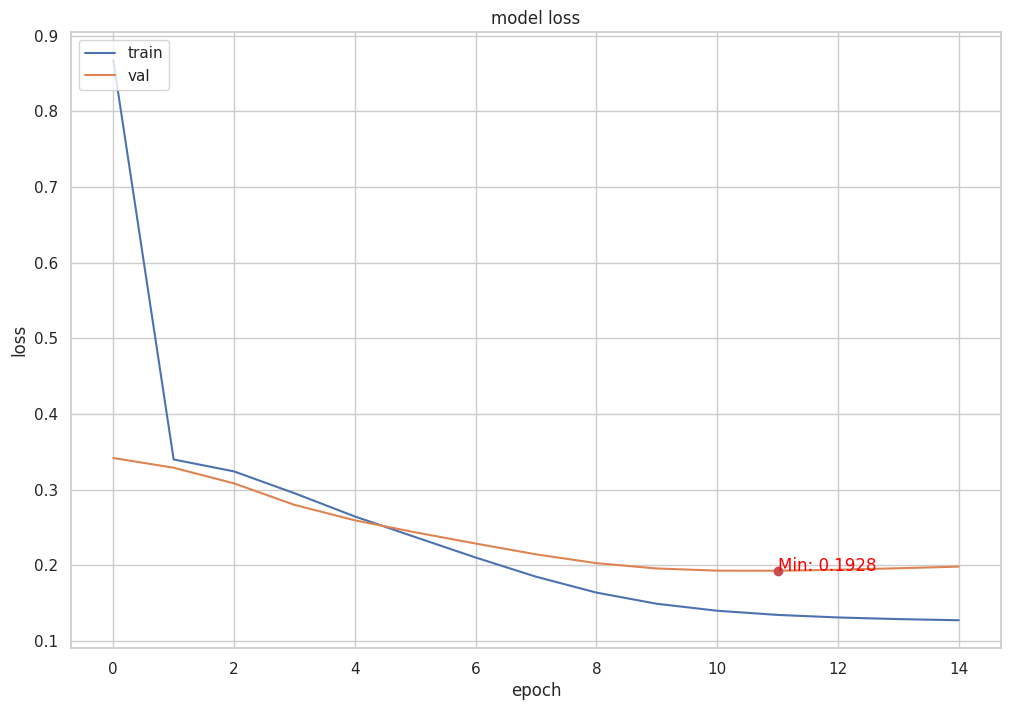

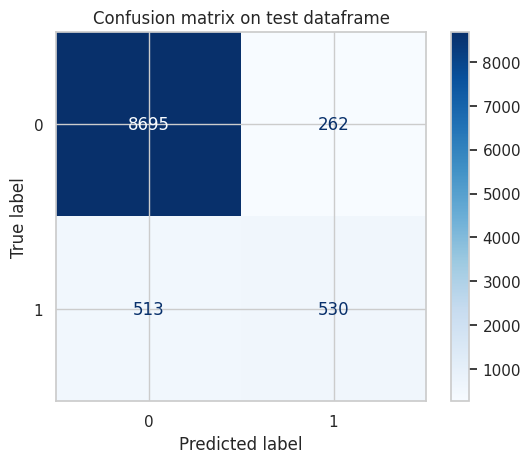

Temps d'exécution : 14 secondes


11

In [321]:
# Temps d'exécution : 15 secondes
MF_NRS.prediction_score(graph_object, nb_epochs=15, algorithm = "NRS", dim_embedding = 1)

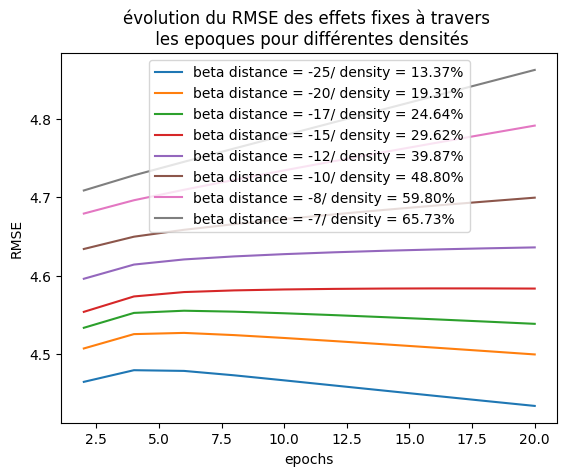

Temps d'exécution : 292 secondes


In [13]:
# Temps d'exécution : 492 secondes
density_ami_rmse_simulation.plot_rmse_epochs(n=10, epochs_step = 2, save=False, algorithm = "NRS")

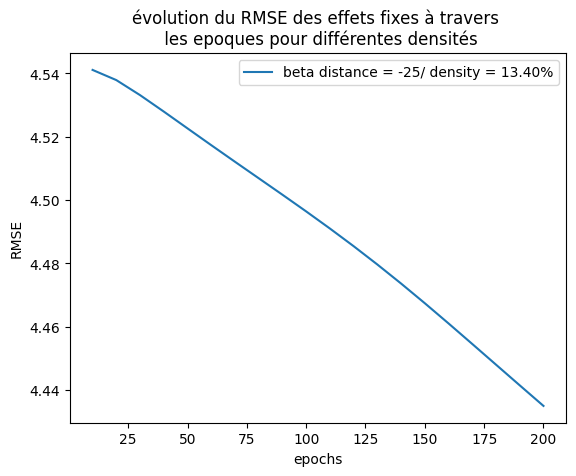

Temps d'exécution : 235 secondes


In [48]:
# Temps d'exécution :  235 secondes
density_ami_rmse_simulation.plot_rmse_epochs(n = 20, sim_beta_distance_array = [-25], save=True, algorithm = "NRS")

### Etudes du Clustering

#### Visualisation

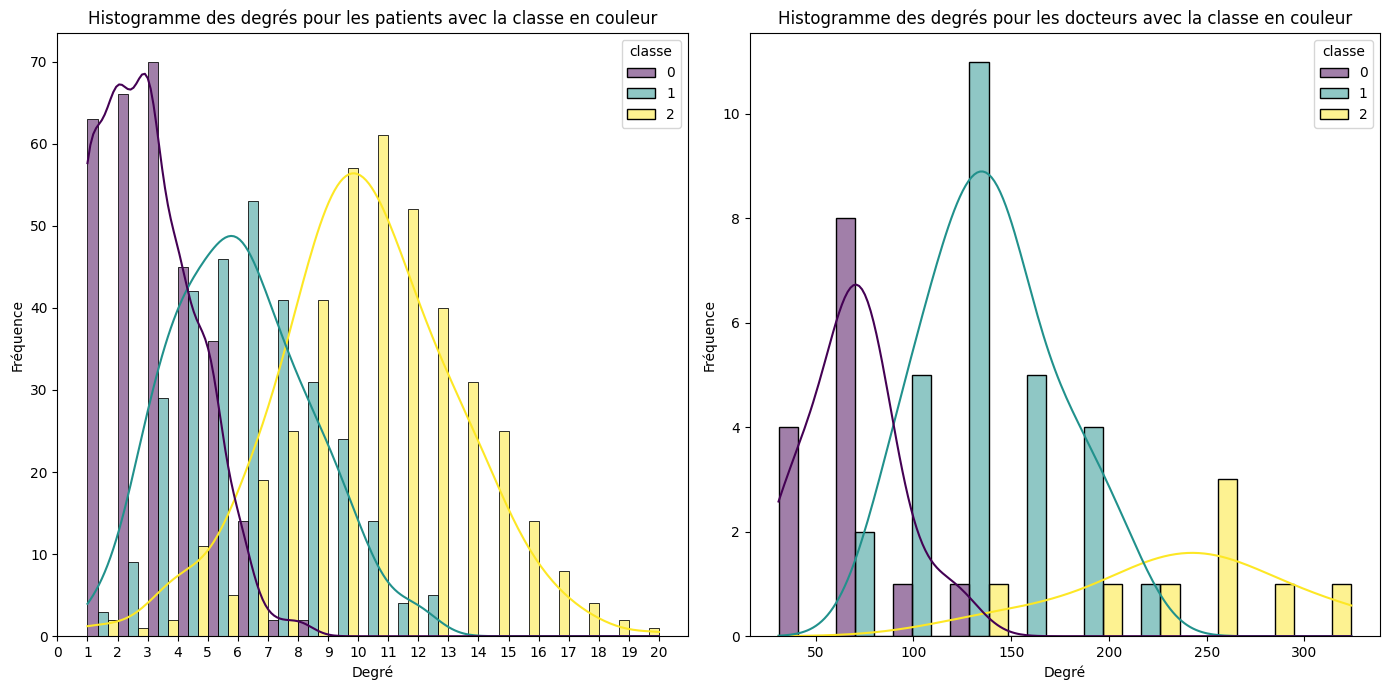

In [37]:
plot_functions.plot_hist_degree(graph_object, hue_class = True, save = False)

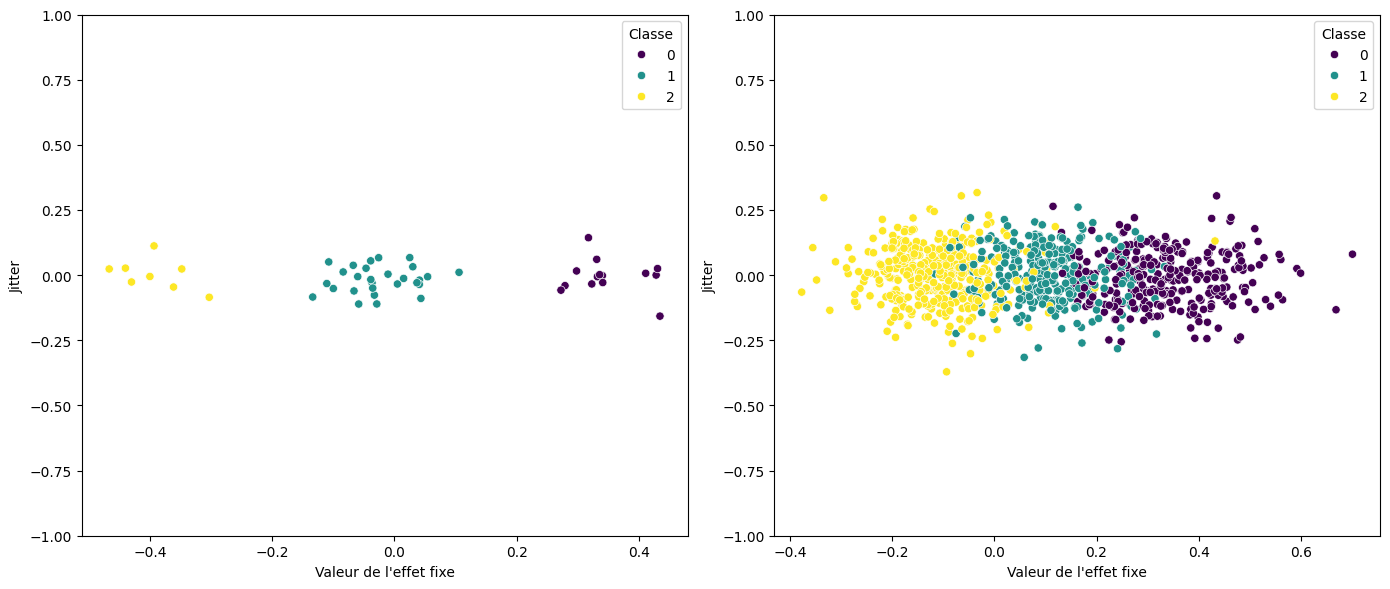

In [36]:
plot_functions.plot_ef_1D(graph_object, ef_patient = ef_patient_hat, ef_doctor = ef_doctor_hat)

#### Clustering et métriques

Inertia: Sum of squared distances of samples to their closest cluster center, weighted by the sample weights if provided.

In [49]:
tab_kmeans = metrique.tab_ami_kmeans_inertia(graph_object, ef_patient= ef_patient_hat, ef_doctor = ef_doctor_hat, save = False,return_ = True)

    K  Inertia patient  AMI patient  Inertia doctor  AMI doctor
0   2         9.671744     0.460689        1.280342    0.410207
1   3         4.448382     0.643347        0.145956    1.000000
2   4         3.018158     0.445753        0.084779    0.676711
3   5         1.741096     0.403119        0.069138    0.550062
4   6         1.356375     0.384343        0.036028    0.469251
5   7         1.062663     0.329781        0.022323    0.438359
6   8         0.834993     0.292353        0.017786    0.392453
7   9         0.707289     0.284169        0.014603    0.328684
8  10         0.557253     0.258179        0.011278    0.315764


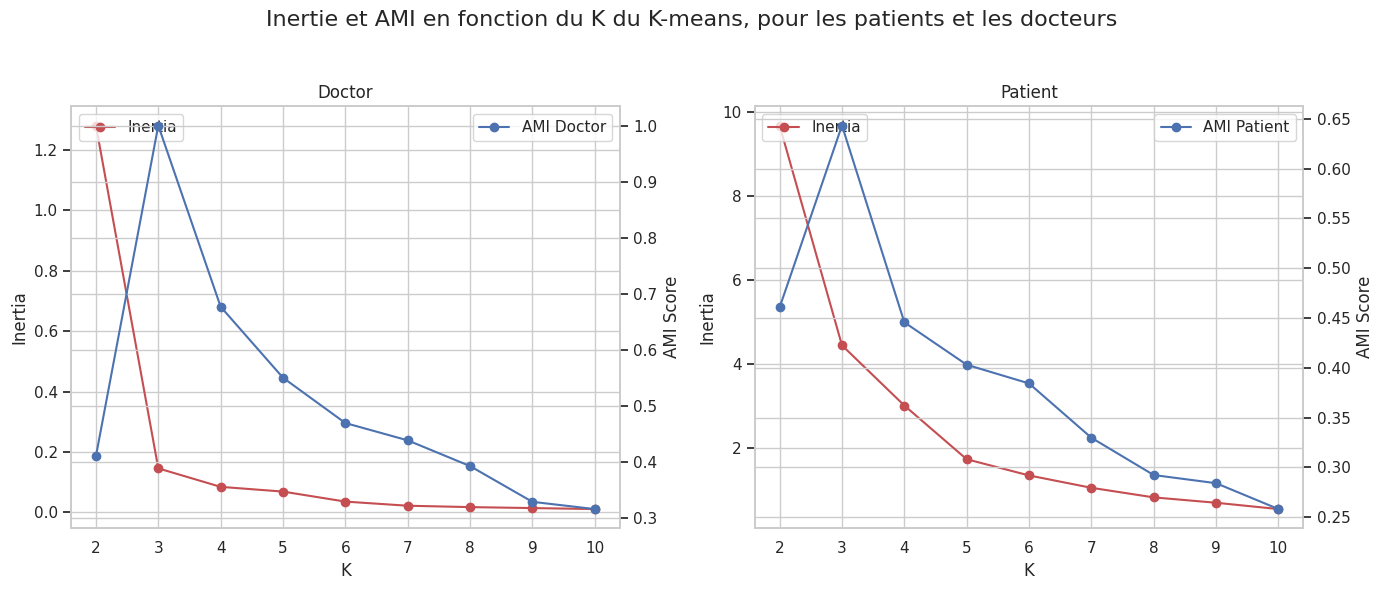

In [65]:
plot_functions.plot_tab_ami_inertia_kmeans(tab_kmeans)

#### AMI et coefficient de régularisation

Simulation 1: done !
Simulation 2: done !
Simulation 3: done !
Simulation 4: done !
Simulation 5: done !
Simulation 6: done !
Simulation 7: done !


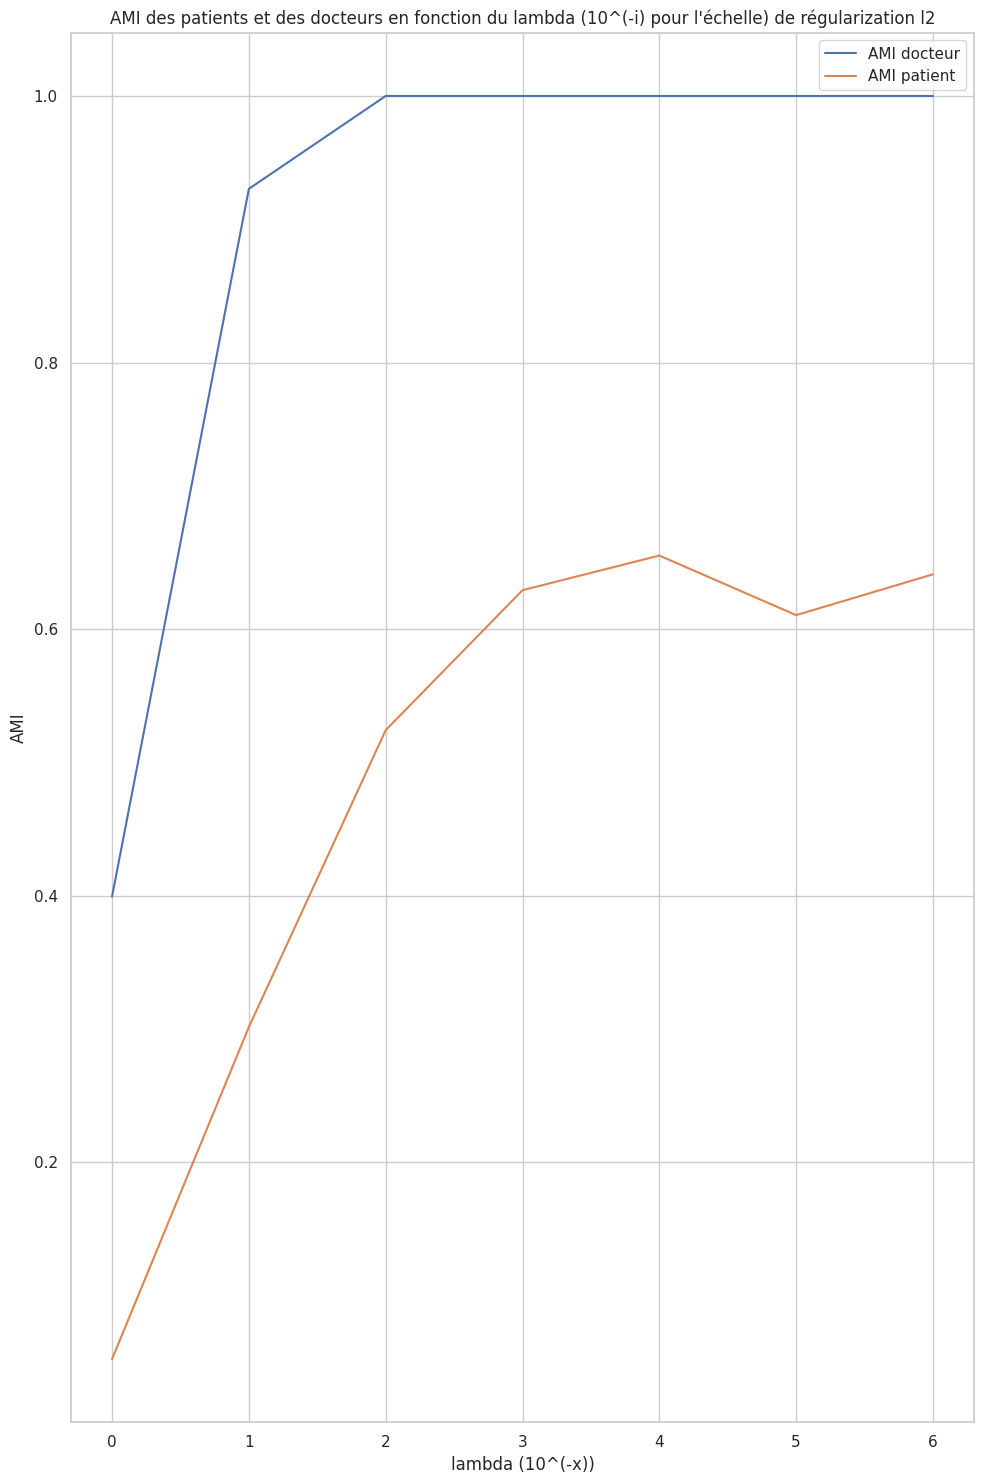

In [221]:
simulation.simulation_ami_lambda( regu_lambdas = np.array([10**(-i) for i in range(7)]), nb_epochs=30, save=True, algorithm = "NRS" )

### Robustesse

In [ ]:
simulation.robustesse_all(100, 0.8, graph_object, nb_epochs = 30, dim_embedding = 1,  algorithm = "NRS")

simulation 1: done
simulation 2: done
simulation 3: done
simulation 4: done
simulation 5: done
simulation 6: done
simulation 7: done
simulation 8: done
simulation 9: done
simulation 10: done
simulation 11: done


## Etude avec EF en dimension 2

### Formation du graphe et "training"

In [298]:
#Exemple de foramtion de graphe avec des EF 2D
alpha_law_means = [[0,1], [1,-1], [2,0]]
psi_law_means = [[1,1], [1,-1], [-1,2]]
identity_matrices = np.array([np.eye(2) for _ in range(3)])


graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -20,
                    dilatation_p = 1.5,
                    dilatation_d = 1.5,
                    alpha_law_means = alpha_law_means,
                    psi_law_means = psi_law_means,
                    psi_law_stds= identity_matrices,
                    alpha_law_stds = identity_matrices,
                    std_multiplier_p=0,
                    std_multiplier_d=0,
                    nb_latent_factors=2)
graph_object.do_the_graph()
print(f"density of the graph: {graph_object.density*100:.2f}%")

density of the graph: 11.19%


In [72]:
# Training
estimates = get_estimations(graph_object.df, nb_epochs=30, show_print=0, algorithm = "NRS", dim_embedding = 2)

# Recuperation des poids au niveau des embeddings
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

### Etude Préliminaires

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Mean Squared Error sur l'échantillon de test : 0.3095773316333591
Precision: 0.73
Recall: 0.71
F1-score: 0.72


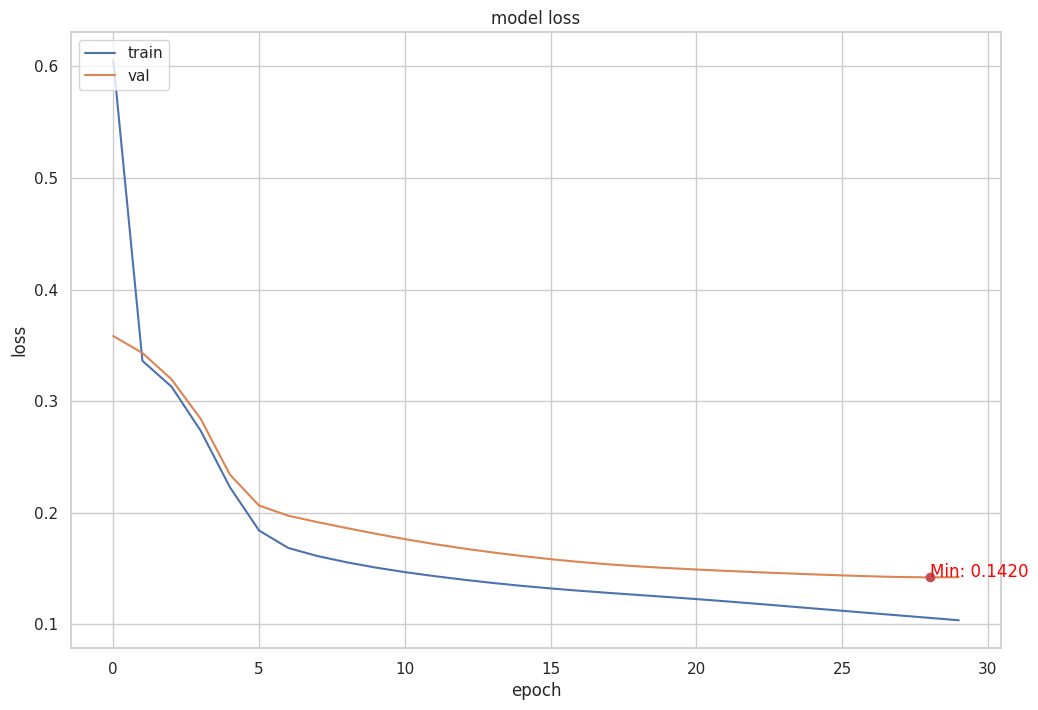

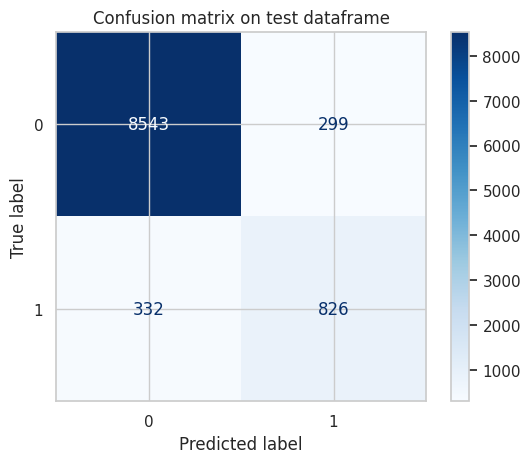

Temps d'exécution : 25 secondes


In [71]:
#Temps d'exécution : 285 secondes
MF_NRS.prediction_score(graph_object, dim_embedding=2, nb_epochs=30, algorithm = "NRS")

### Etudes Clustering

#### Visualisation

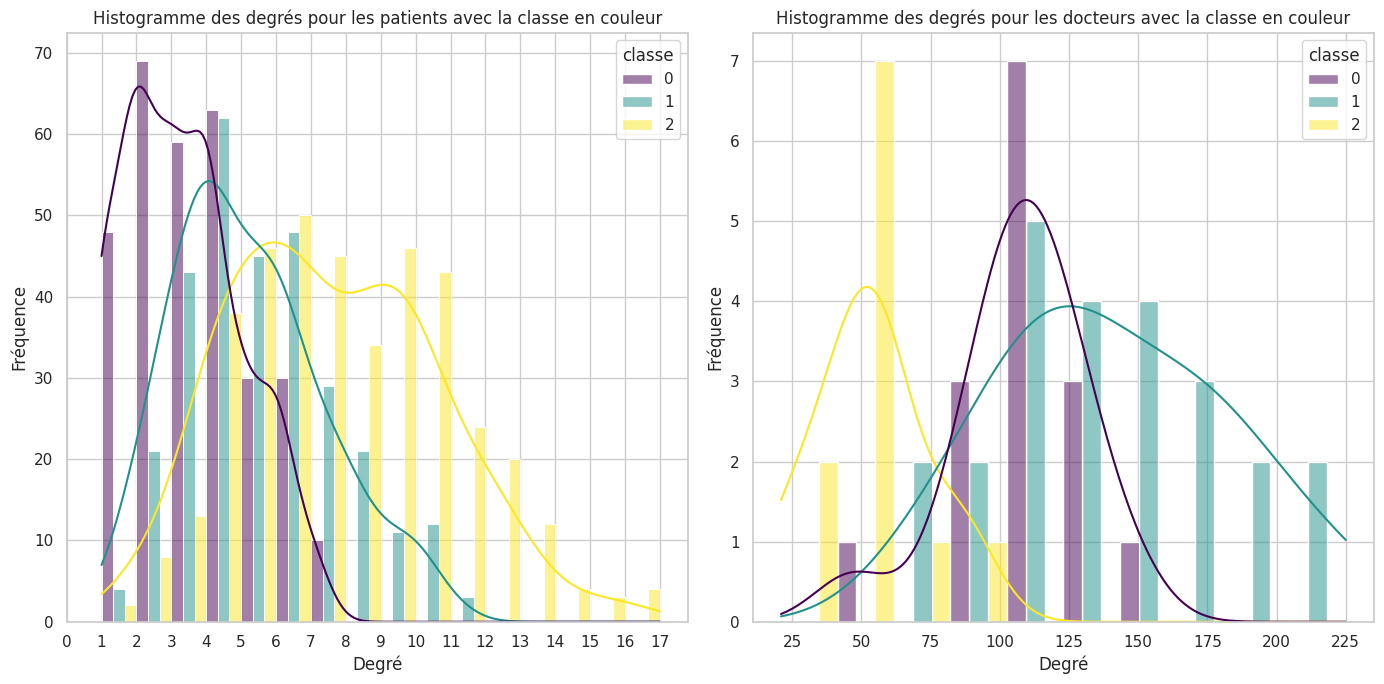

In [103]:
plot_functions.plot_hist_degree(graph_object, hue_class = True, save = False)

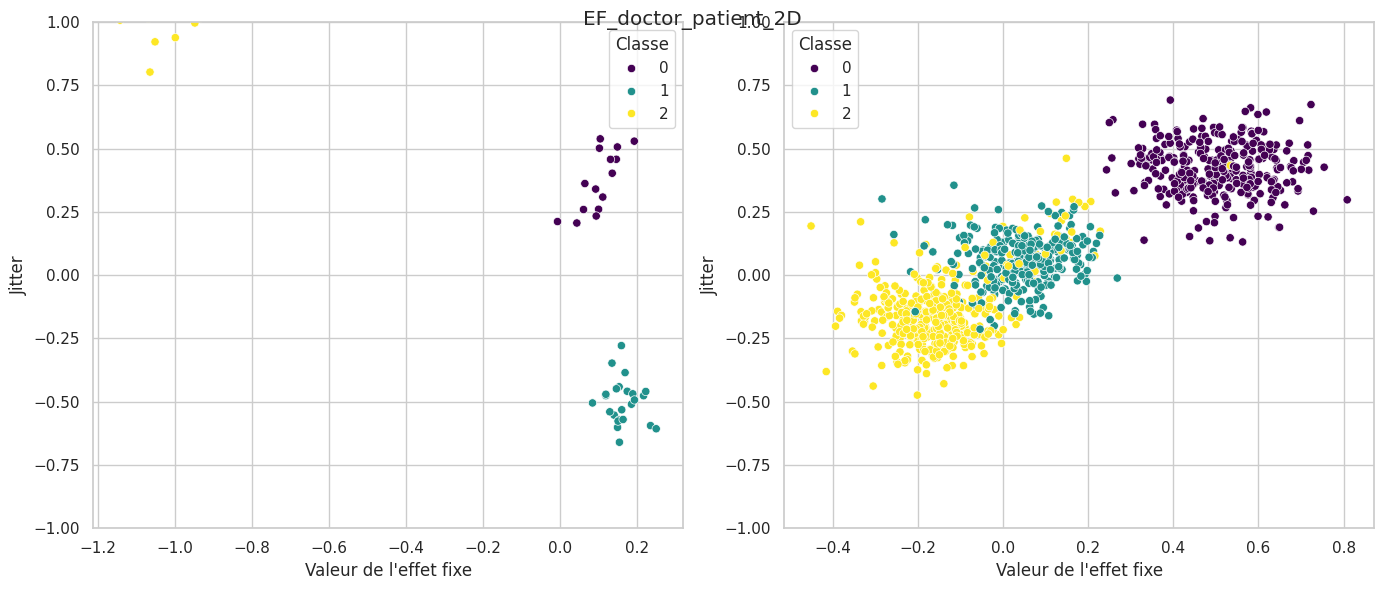

In [74]:
plot_functions.plot_ef_2D(graph_object, ef_patient = ef_patient_hat, ef_doctor = ef_doctor_hat)

#### Clustering et métriques

In [75]:
tab_kmeans = metrique.tab_ami_kmeans_inertia(graph_object, ef_patient= ef_patient_hat, ef_doctor = ef_doctor_hat, save = False,return_ = True)

    K  Inertia patient  AMI patient  Inertia doctor  AMI doctor
0   2        36.584503     0.534746        7.654437    0.458954
1   3        17.681396     0.808889        0.587025    1.000000
2   4        15.199844     0.695825        0.402170    0.897342
3   5        13.021120     0.558523        0.334415    0.839808
4   6        11.440870     0.534323        0.241760    0.712745
5   7         9.791423     0.420272        0.213516    0.691754
6   8         8.429238     0.370158        0.172516    0.470544
7   9         7.559444     0.329618        0.128600    0.400755
8  10         6.870308     0.305368        0.112625    0.310658


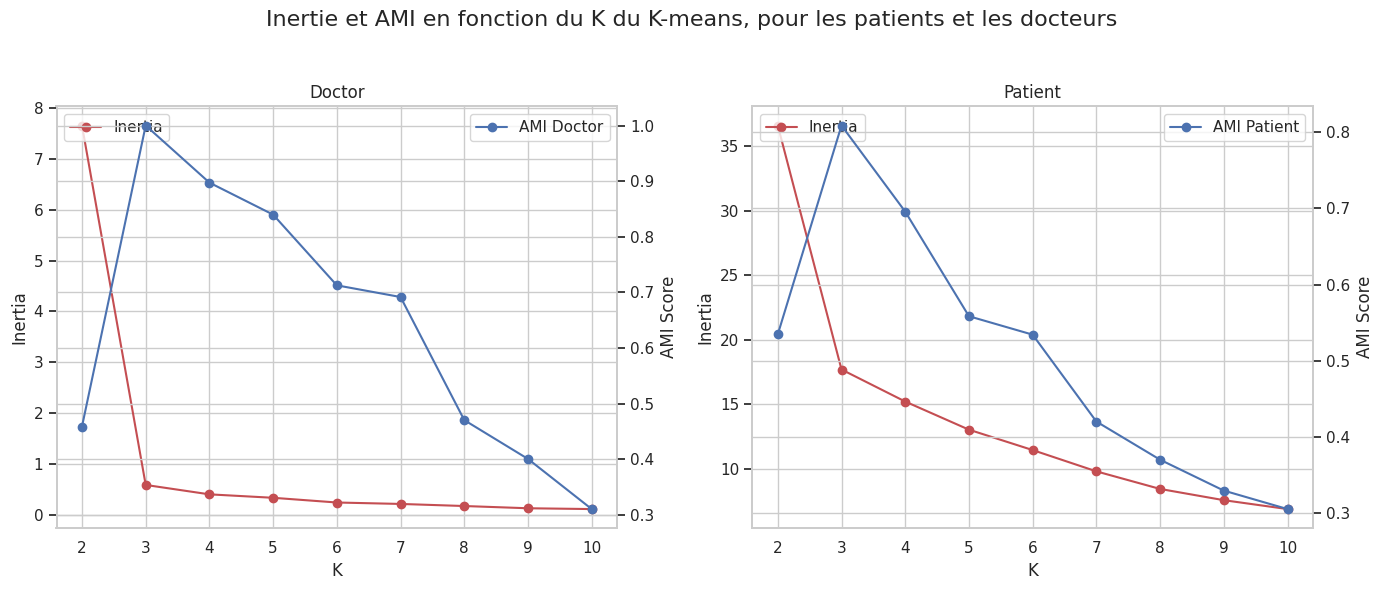

In [76]:
plot_functions.plot_tab_ami_inertia_kmeans(tab_kmeans)

### Robustesse

In [ ]:
simulation.robustesse_all(100, 0.8, graph_object, nb_epochs = 30, dim_embedding = 2,  algorithm = "NRS")

simulation 1: done


## Etude avec EF en dimension 5 (sphère)

### Formation du graphe et "training"

In [312]:
#Exemple de foramtion de graphe avec des EF 5D (gaussian sphere)
identity_matrices = np.array([np.eye(5) for _ in range(6)])


graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -25,
                    psi_law_stds= identity_matrices,
                    alpha_law_stds = identity_matrices,
                    std_multiplier_p=0.3,
                    std_multiplier_d=0.5,
                    nb_latent_factors=5,
                    gaussian_sphere = True,
                    radius = 4,
                    seed=12)
graph_object.do_the_graph()
print(f"density of the graph: {graph_object.density*100:.2f}%")

density of the graph: 10.83%


In [183]:
# Training
estimates = get_estimations(graph_object.df, nb_epochs=20, show_print=0, algorithm = "NRS", dim_embedding = 3)

# Recuperation des poids au niveau des embeddings
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

### Etudes Préliminaires

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Mean Squared Error sur l'échantillon de test : 0.3151439120355152
Precision: 0.72
Recall: 0.66
F1-score: 0.69


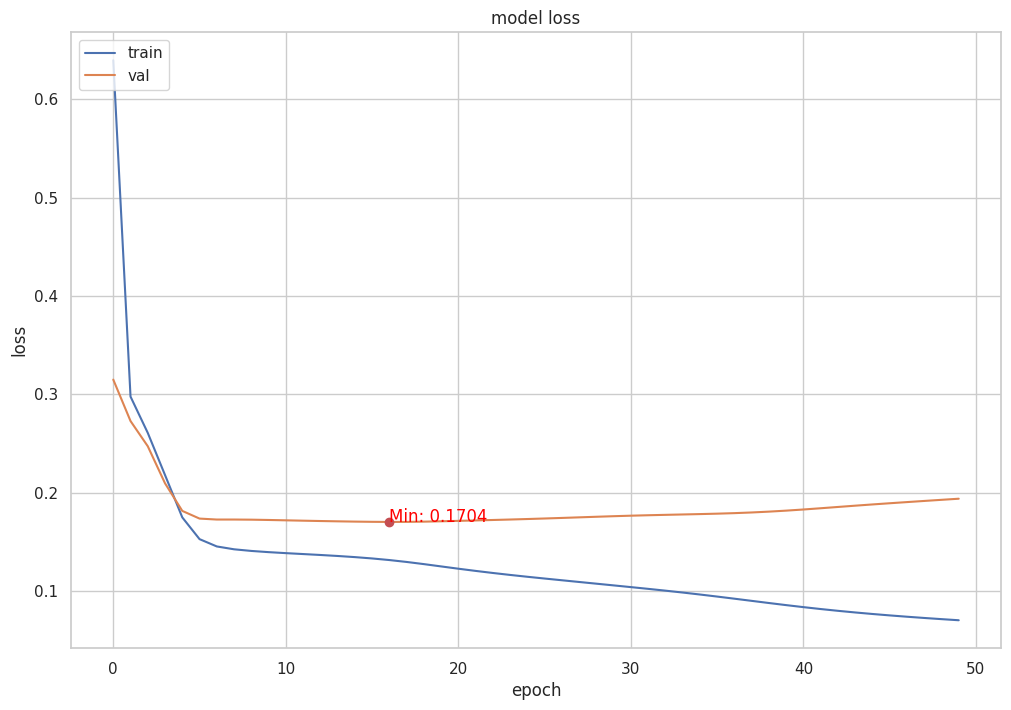

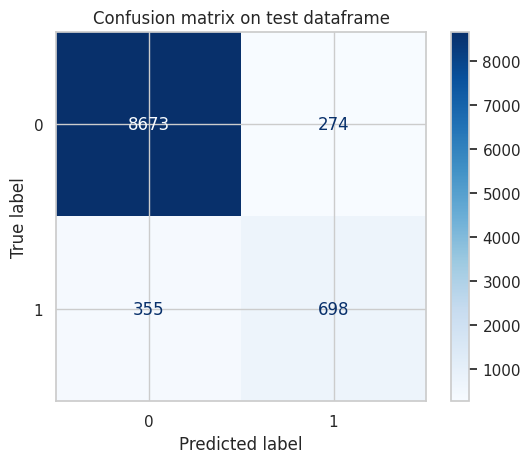

Temps d'exécution : 47 secondes


In [88]:
MF_NRS.prediction_score(graph_object, dim_embedding=5, nb_epochs=50, algorithm = "NRS")

### Etudes Clustering

#### Visualisation

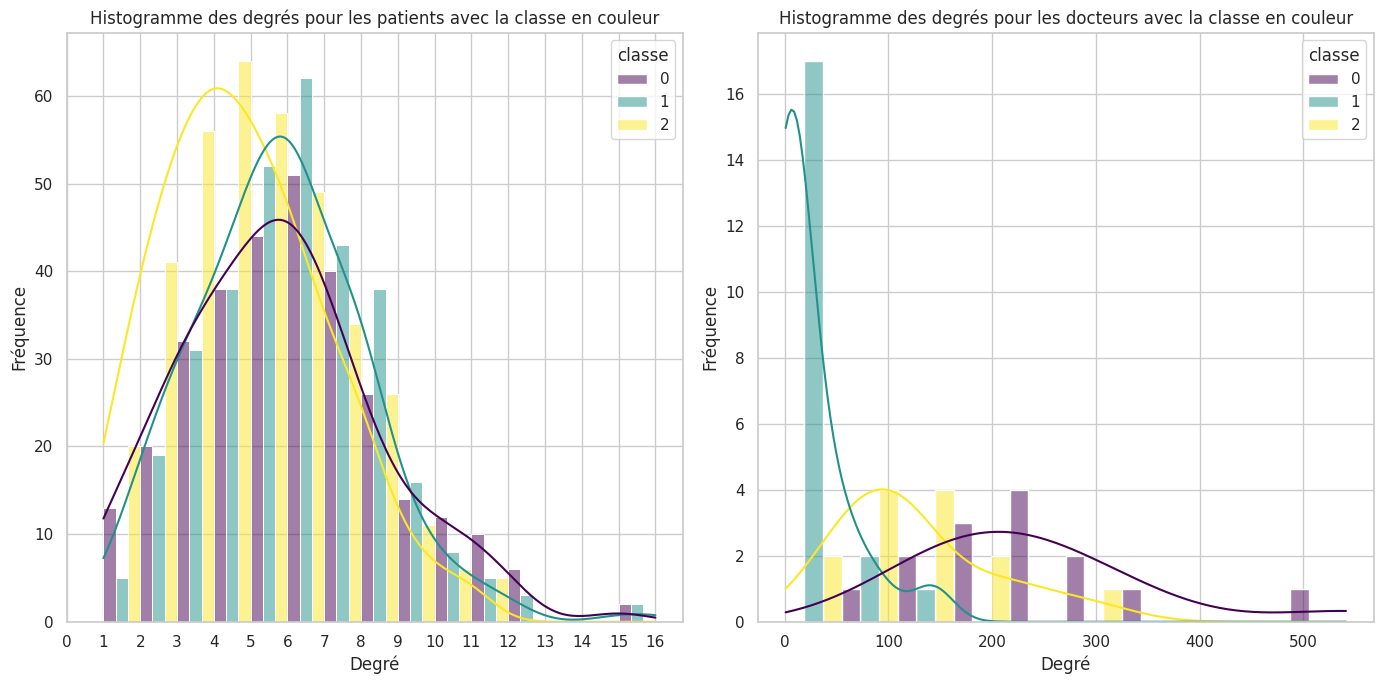

In [313]:
plot_functions.plot_hist_degree(graph_object, hue_class = True, save = False)

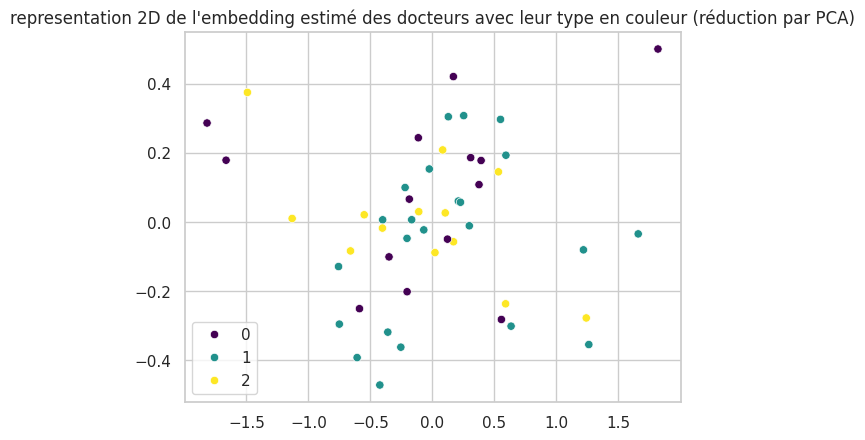

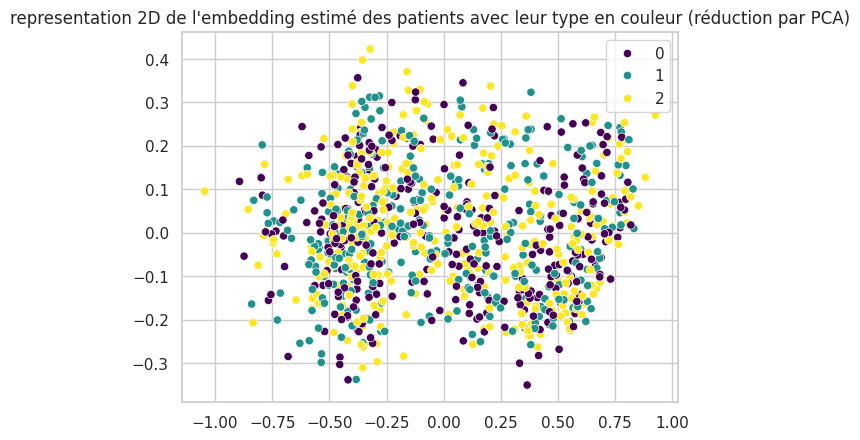

Temps d'exécution : 0 secondes


In [314]:
plot_functions.plot_ef_RD(graph_object, ef_patient_hat, ef_doctor_hat, label_doctor = None, label_patient = None, RD_method = "PCA", save = False)

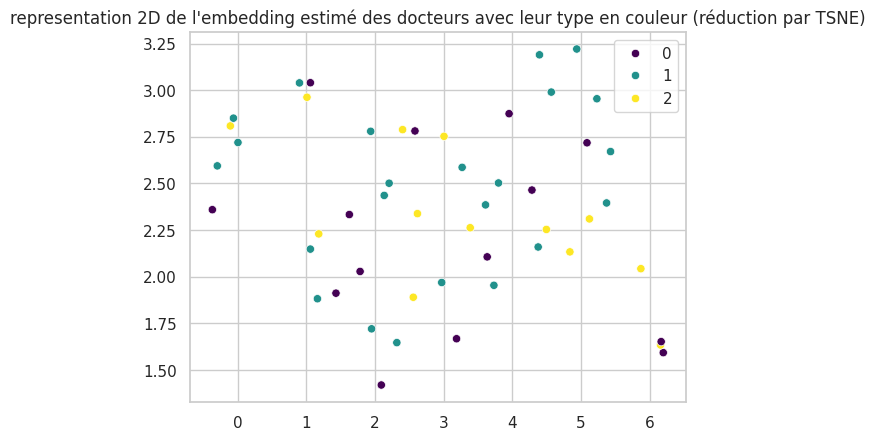

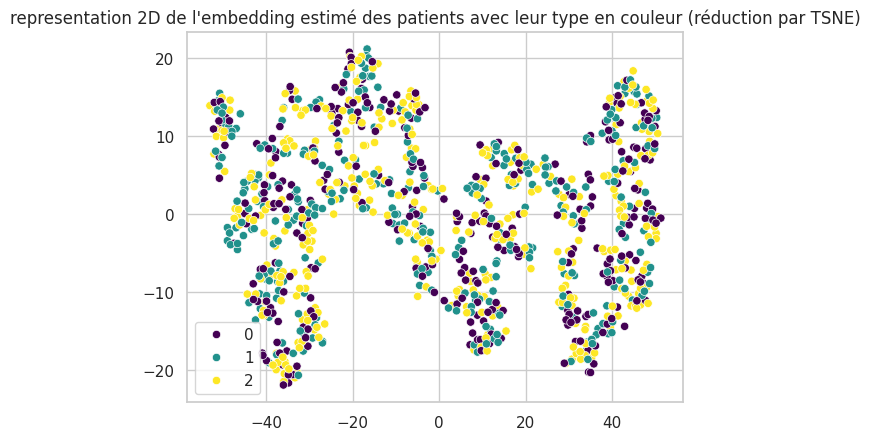

Temps d'exécution : 7 secondes


In [315]:
plot_functions.plot_ef_RD(graph_object, ef_patient_hat, ef_doctor_hat, label_doctor = None, label_patient = None, RD_method = "TSNE", save = False)

In [ ]:
plot_functions.plot_ef_RD(graph_object, ef_patient_hat, ef_doctor_hat, label_doctor = None, label_patient = None, RD_method = "UMAP", save = False)

#### Clustering et métriques

In [186]:
tab_kmeans = metrique.tab_ami_kmeans_inertia(graph_object, ef_patient= ef_patient_hat, ef_doctor = ef_doctor_hat, save = False,return_ = True)

    K  Inertia patient  AMI patient  Inertia doctor  AMI doctor
0   2        67.112206     0.325191       15.399682    0.157893
1   3        44.687805     0.460005        8.887749    0.318979
2   4        35.962395     0.329882        4.831122    0.449345
3   5        31.929129     0.294270        3.659822    0.276156
4   6        25.329586     0.257051        3.379792    0.269127
5   7        21.793076     0.226875        2.962219    0.229742
6   8        19.735113     0.230330        2.385139    0.216342
7   9        17.745644     0.226263        2.150316    0.198388
8  10        16.301010     0.204558        1.554073    0.182994


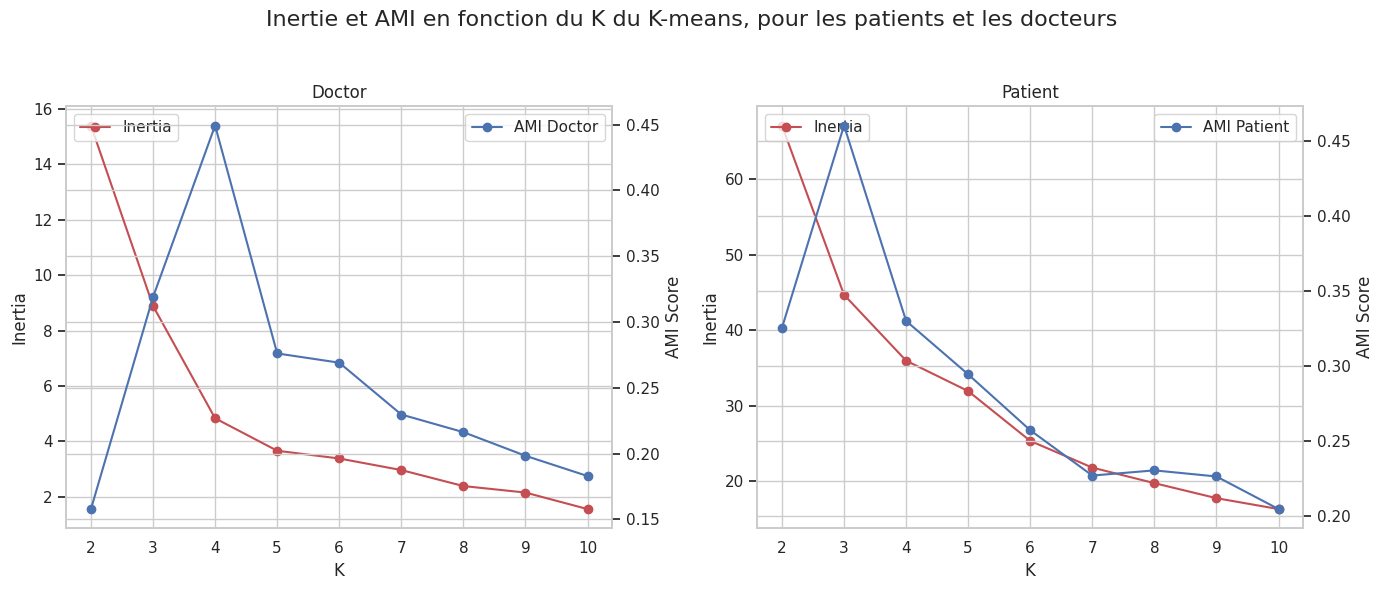

In [187]:
plot_functions.plot_tab_ami_inertia_kmeans(tab_kmeans)

### Robustesse

In [316]:
simulation.robustesse_all(100, 0.8, graph_object, nb_epochs = 30, dim_embedding = 5, algorithm = "NRS")

simulation 1: done
simulation 2: done
simulation 3: done
simulation 4: done
simulation 5: done
simulation 6: done
simulation 7: done
simulation 8: done
simulation 9: done
simulation 10: done
simulation 11: done
simulation 12: done
simulation 13: done
simulation 14: done
simulation 15: done
simulation 16: done
simulation 17: done
simulation 18: done
simulation 19: done
simulation 20: done
simulation 21: done
simulation 22: done
simulation 23: done
simulation 24: done
simulation 25: done
simulation 26: done
simulation 27: done
simulation 28: done
simulation 29: done
simulation 30: done
simulation 31: done
simulation 32: done
simulation 33: done
simulation 34: done
simulation 35: done
simulation 36: done
simulation 37: done
simulation 38: done
simulation 39: done
simulation 40: done
simulation 41: done
simulation 42: done
simulation 43: done
simulation 44: done
simulation 45: done
simulation 46: done
simulation 47: done
simulation 48: done
simulation 49: done
simulation 50: done
simulatio